# ProfileMLP + explicit bilinear (Potts) head -- recovering the J-dominated extreme variants

Follow-up to `MLP_for_anticorrelated_weights.ipynb`. That notebook established, on the
real-AAV9-derived `F_viab`/`J_viab` ground truth (anticorrelated `F_sel`/`J_sel`,
`anticorrelation=0.2`):

1. The TRUE top-50,000 variants (by `compute_score = F_part + J_part`) are dominated by `J`
   (pairwise/epistatic), not `F` (additive) -- J's share of the score variance is much larger
   in this extreme tail than in a random sample.
2. An F-only ablation reproduces only the well-predicted block and misses the J-driven block
   entirely -- consistent with a plain `ProfileMLP` under-fitting `J` because it has to
   approximate a bilinear structure implicitly through hidden-layer nonlinearity, instead of
   being given that structure directly.

`compute_score` is *exactly* linear in single-site indicators plus pairwise indicators:
`F[s_i, i] + J[i, j, s_i, s_j]`. This notebook adds an explicit bilinear/Potts head to
`ProfileMLP` -- `pred = MLP(x) + sum_{i<j} x_i^T W_ij x_j` -- which mirrors `J`'s own indicator
form exactly (since `x` is one-hot, `x_i^T W_ij x_j == W_ij[s_i, s_j]`), and checks whether
that alone recovers the previously-missed block. Trains a baseline plain `ProfileMLP` and a
`ProfileMLP` + bilinear head side by side, on the identical train/val split, then compares both
against the TRUE top-50,000 variants from the SAME ground-truth landscape and cached datasets
as `MLP_for_anticorrelated_weights.ipynb`.

## 0. Setup

In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# Must run before the first `import jax` anywhere -- same convention as
# MLP_for_anticorrelated_weights.ipynb.

In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from flax import nnx
from typing import Optional
import optax
from tqdm.auto import tqdm

from sequence_classesV1 import *
from analysisV1 import *
from initialize_weights import (
    load_F_viab_aav9_mlp, load_J_viab_aav9_mlp,
    initialize_anticorrelated_weights,
    NUM_AMINO_ACIDS, NUM_POSITIONS,
)

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend: gpu -- devices: [CudaDevice(id=0)]


## 1. Ground truth + cached datasets

Same `F_viab`/`J_viab` (real AAV9) and `F_sel_anti`/`J_sel_anti` (`anticorrelation=0.2`,
`key=10`) as `MLP_for_anticorrelated_weights.ipynb`, and the same `sequences`/`sequences2`
(identical seeds), so `dataset_filename` resolves to the exact CSVs that notebook already
cached on disk. Constructing a `ProtocolV3` is cheap (just sets attributes); only
`loop_DE()`/`N_loop_DE()` runs the expensive NGS/PCR simulation, so `log_enr_viab`/
`log_enr_sel` are passed as `None` below -- `build_or_load_dataset` only touches them on a
cache MISS, and these caches already exist. If this raises `FileNotFoundError`, run
`MLP_for_anticorrelated_weights.ipynb`'s Part 1 / "another dataset" cells first to regenerate
them.

F_viab shape: (20, 7)   J_viab shape: (7, 7, 20, 20)


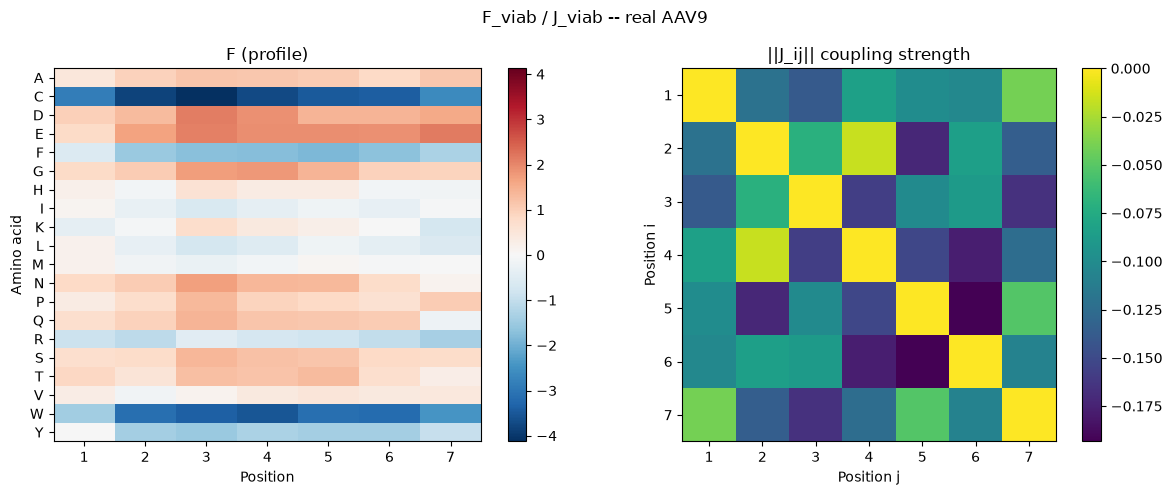

In [3]:
F_viab = load_F_viab_aav9_mlp()
J_viab = load_J_viab_aav9_mlp()

anticorrelation = 0.2
F_sel_anti, J_sel_anti = initialize_anticorrelated_weights(jax.random.key(10), F_viab, J_viab, anticorrelation)

print(f"F_viab shape: {F_viab.shape}   J_viab shape: {J_viab.shape}")
_ = plot_teacher_weights(F_viab, J_viab, title="F_viab / J_viab -- real AAV9")
plt.show()

In [4]:
def dataset_filename(protocol, label):
    def fmt(v):
        return f"{float(v):g}".replace(".", "")

    if protocol.noise_viab == protocol.noise_sel:
        noise_part = f"noise{fmt(protocol.noise_viab)}"
    else:
        noise_part = f"noiseviab{fmt(protocol.noise_viab)}_noisesel{fmt(protocol.noise_sel)}"

    ngs_part = "multinomial" if protocol.multinomialNGS else "nbinom"

    return (f"diversity{protocol.d0}_Tsel{fmt(protocol._T_sel)}"
            f"_Tviab{fmt(protocol._T_viab)}_{noise_part}_{ngs_part}_{label}.csv")


def build_or_load_dataset(protocol, sequences, log_enr_viab, log_enr_sel, label):
    """(sequence, target1=viability log-enrichment, target2=selectivity log-enrichment)
    dataset for this protocol's parameters -- identical to
    MLP_for_anticorrelated_weights.ipynb's version. Loads the CSV from disk if it was already
    generated for this exact (diversity, T_sel, T_viab, noise, label) combination, else builds
    and saves it."""
    path = dataset_filename(protocol, label)
    if os.path.exists(path):
        print(f"{path} already exists -- loading from disk")
        return pd.read_csv(path)

    seq_strings = ["".join(AA_LABELS[a] for a in row) for row in np.asarray(sequences)]
    df = pd.DataFrame({"sequence": seq_strings, "target1": log_enr_viab, "target2": log_enr_sel})
    df.to_csv(path, index=False)
    print(f"saved {path} ({len(df)} rows)")
    return df

In [5]:
key = jax.random.key(0)
key, k_seq = jax.random.split(key)

N = 20_000
sequences = jax.random.randint(k_seq, shape=(N, NUM_POSITIONS), minval=0, maxval=NUM_AMINO_ACIDS)

protocol_anti = ProtocolV3(multinomialNGS=True, N0=1_000_000_000, N1=500_000_000,
        dilution_factor=10, sequences=sequences, D=1e9,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel_anti, J_sel=J_sel_anti,
        noise_viab=0.5, noise_sel=0.5, T_sel=1, T_viab=1,
        )

dataset_anti = build_or_load_dataset(protocol_anti, sequences, None, None, label="ac")
print(f"dataset_anti: {len(dataset_anti):,} rows")
dataset_anti.head()

diversity20000_Tsel1_Tviab1_noise05_ac.csv already exists -- loading from disk
dataset_anti: 20,000 rows


,sequence,target1,target2
0,DDTSNIP,1.844218,-10.276351
1,MSTDFNG,-0.194703,-0.012255
2,CQNSWCF,-7.772977,-3.401197
3,CRCHSEA,-9.877888,-0.693147
4,QAFNMTQ,-3.928573,0.309296


In [6]:
key = jax.random.key(42)
key, k_seq = jax.random.split(key)

N = 2_000_000
sequences2 = jax.random.randint(k_seq, shape=(N, NUM_POSITIONS), minval=0, maxval=NUM_AMINO_ACIDS)

protocol_anti2 = ProtocolV3(multinomialNGS=True, N0=1_000_000_000, N1=500_000_000,
        dilution_factor=10, sequences=sequences2, D=1e9,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel_anti, J_sel=J_sel_anti,
        noise_viab=0.5, noise_sel=0.5, T_sel=1, T_viab=1,
        )

dataset_anti2 = build_or_load_dataset(protocol_anti2, sequences2, None, None, label="ac")
print(f"dataset_anti2: {len(dataset_anti2):,} rows")

diversity2000000_Tsel1_Tviab1_noise05_ac.csv already exists -- loading from disk
dataset_anti2: 2,000,000 rows


## 2. Encode sequences, train/val/test split

In [7]:
def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

seq_bytes  = np.frombuffer("".join(dataset_anti["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix = lut[seq_bytes].reshape(len(dataset_anti), NUM_POSITIONS)
seq_oh     = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[seq_matrix].reshape(len(dataset_anti), -1)

y_viab_all = dataset_anti["target1"].to_numpy()
y_sel_all  = dataset_anti["target2"].to_numpy()

idx_train, idx_test = train_test_split(np.arange(len(dataset_anti)), test_size=0.5, random_state=0)
X_train_full, X_test = seq_oh[idx_train], seq_oh[idx_test]
y_viab_train, y_viab_test = y_viab_all[idx_train], y_viab_all[idx_test]
y_sel_train,  y_sel_test  = y_sel_all[idx_train],  y_sel_all[idx_test]

print(f"X_train_full shape: {X_train_full.shape}  X_test shape: {X_test.shape}")

X_train_full shape: (10000, 140)  X_test shape: (10000, 140)


## 3. Models: plain `ProfileMLP` (baseline) vs. `ProfileMLP` + bilinear Potts head

`BilinearHead` computes `sum_{i<j} x_i^T W_ij x_j` where `x_i` is the one-hot slice at
position `i` -- since `x` is one-hot, `x_i^T W_ij x_j` picks out exactly `W_ij[s_i, s_j]`, the
SAME indicator-feature form as the true model's `J[i, j, a, b]` (see
`sequence_classesV1.Protocol.compute_score`). `ProfileMLPBilinear` adds this residually to the
existing `ProfileMLP` branch, so the MLP still handles `F` (and any leftover nonlinear
structure) while the head gets direct, unmediated access to the pairwise term.

In [8]:
class ProfileMLP(nnx.Module):
    """
    MLP over the one-hot encoded per-position sequence (L=7 positions x A=20 amino acids
    -> 140 indicator features) -> scalar score. Identical to
    MLP_for_anticorrelated_weights.ipynb's ProfileMLP (Linear + BatchNorm + Dropout + gelu).
    """

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (256, 128),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x: jax.Array, *, train: bool, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        x = self.linear1(x)
        x = self.batchnorm1(x, use_running_average=not train)
        x = self.dropout1(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        x = self.linear2(x)
        x = self.batchnorm2(x, use_running_average=not train)
        x = self.dropout2(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        return self.linear3(x).squeeze(-1)

In [9]:
class BilinearHead(nnx.Module):
    """
    Explicit pairwise coupling term: score += sum_{i<j} x_i^T W_ij x_j. Because x is one-hot,
    x_i^T W_ij x_j == W[k, s_i, s_j] exactly -- the same indicator-feature form as the true
    model's J[i,j,a,b] -- so this gives the model direct access to the pairwise structure
    instead of having to approximate it implicitly through hidden-layer nonlinearity.
    """

    def __init__(self, L: int, A: int, *, rngs: nnx.Rngs):
        self.L, self.A = L, A
        self.pairs_i = jnp.array([i for i in range(L) for j in range(i + 1, L)])
        self.pairs_j = jnp.array([j for i in range(L) for j in range(i + 1, L)])
        n_pairs = len(self.pairs_i)
        # Small init, same scale convention as J_viab/J_sel's own (/10 of a unit normal).
        self.W = nnx.Param(0.1 * jax.random.normal(rngs.params(), (n_pairs, A, A)))

    def __call__(self, x_onehot: jax.Array) -> jax.Array:
        batch = x_onehot.shape[0]
        x   = x_onehot.reshape(batch, self.L, self.A)
        x_i = x[:, self.pairs_i, :]   # (batch, n_pairs, A)
        x_j = x[:, self.pairs_j, :]   # (batch, n_pairs, A)
        contrib = jnp.einsum('bpa,pac,bpc->bp', x_i, self.W[...], x_j)
        return contrib.sum(axis=1)


class ProfileMLPBilinear(nnx.Module):
    """ProfileMLP's additive MLP branch + BilinearHead, added residually."""

    def __init__(self, input_dim: int, L: int, A: int, hidden_dims: tuple[int, int] = (128, 64),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        self.mlp      = ProfileMLP(input_dim, hidden_dims, dropout_rate, rngs=rngs)
        self.bilinear = BilinearHead(L, A, rngs=rngs)

    def __call__(self, x: jax.Array, *, train: bool, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        return self.mlp(x, train=train, rngs=rngs) + self.bilinear(x)

In [10]:
@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    """
    x : (batch, L*A) one-hot encoded per-position amino-acid indicators
    y : (batch,) target log enrichment
    """
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.jit
def predict_log_enrichment(model, x):
    return model(x, train=False)


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan(carry, xb, yb):
    """Fuses one epoch's mini-batch train_step calls into a single compiled nnx.scan
    instead of a Python for-loop issuing one XLA dispatch per batch."""
    model, optimizer, rngs = carry
    loss = train_step(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss

In [11]:
def train_profile_mlp(X_train, y_train, X_val, y_val, hidden_dims=(128, 64),
                       dropout_rate=0.1, epochs=300, batch_size=256,
                       peak_lr=1e-3, final_lr=1e-5, weight_decay=0,
                       patience=20, seed=0, verbose=True, model=None):
    """
    model : optional existing model (ProfileMLP or ProfileMLPBilinear) to continue training
    from (warm start) instead of initializing a fresh ProfileMLP -- this is how the bilinear
    model gets trained below, by pre-constructing a ProfileMLPBilinear and passing it in here.
    """
    rngs = nnx.Rngs(seed)
    if model is None:
        model = ProfileMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                            dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs), desc="Training", disable=not verbose):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm      = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)

        (model, optimizer, rngs), step_losses = train_epoch_scan(
            (model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx]
        )
        train_loss = float(jnp.mean(step_losses))
        val_loss   = float(eval_step(model, X_val, y_val))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val MSE={best_val:.4f})")
                break

    nnx.update(model, best_state)
    return model, history

## 4. Train baseline and bilinear models (viability + selectivity)

In [12]:
Xtr_viab, ytr_viab, Xva_viab, yva_viab = split_train_val(X_train_full, y_viab_train, val_frac=0.15, seed=0)
Xtr_sel,  ytr_sel,  Xva_sel,  yva_sel  = split_train_val(X_train_full, y_sel_train,  val_frac=0.15, seed=1)
input_dim = X_train_full.shape[1]
print(f"train: {len(Xtr_viab):,}  val: {len(Xva_viab):,}  test: {len(X_test):,}  input_dim: {input_dim}")

print("Training baseline ProfileMLP (viability)...")
model_viab_baseline, hist_viab_baseline = train_profile_mlp(Xtr_viab, ytr_viab, Xva_viab, yva_viab, seed=0)

print("Training baseline ProfileMLP (selectivity)...")
model_sel_baseline, hist_sel_baseline = train_profile_mlp(Xtr_sel, ytr_sel, Xva_sel, yva_sel, seed=1)

train: 8,500  val: 1,500  test: 10,000  input_dim: 140
Training baseline ProfileMLP (viability)...


Training:  48%|████▊     | 144/300 [00:05<00:06, 24.20it/s]


Early stopping at epoch 144 (best val MSE=1.0014)
Training baseline ProfileMLP (selectivity)...


Training:  31%|███       | 92/300 [00:01<00:03, 54.40it/s]

Early stopping at epoch 92 (best val MSE=2.1473)


In [13]:
print("Training ProfileMLP + bilinear head (viability)...")
bilinear_viab_init = ProfileMLPBilinear(input_dim, NUM_POSITIONS, NUM_AMINO_ACIDS,
                                         hidden_dims=(128, 64), dropout_rate=0.1, rngs=nnx.Rngs(0))
model_viab_bilinear, hist_viab_bilinear = train_profile_mlp(
    Xtr_viab, ytr_viab, Xva_viab, yva_viab, model=bilinear_viab_init, seed=0)

print("Training ProfileMLP + bilinear head (selectivity)...")
bilinear_sel_init = ProfileMLPBilinear(input_dim, NUM_POSITIONS, NUM_AMINO_ACIDS,
                                        hidden_dims=(128, 64), dropout_rate=0.1, rngs=nnx.Rngs(1))
model_sel_bilinear, hist_sel_bilinear = train_profile_mlp(
    Xtr_sel, ytr_sel, Xva_sel, yva_sel, model=bilinear_sel_init, seed=1)

Training ProfileMLP + bilinear head (viability)...


Training:  51%|█████     | 153/300 [00:03<00:03, 45.81it/s]


Early stopping at epoch 153 (best val MSE=0.9294)
Training ProfileMLP + bilinear head (selectivity)...


Training:  39%|███▊      | 116/300 [00:02<00:03, 55.00it/s]


Early stopping at epoch 116 (best val MSE=2.0218)


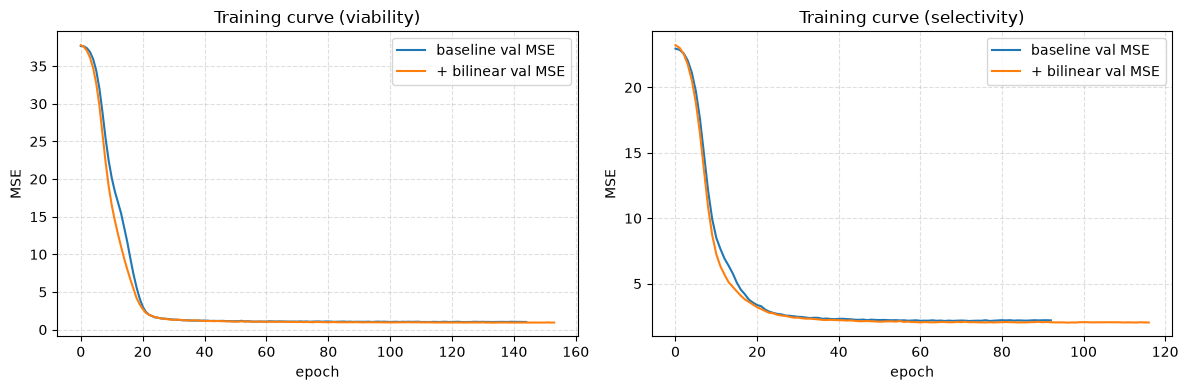

model                      viab test r   sel test r
baseline (plain MLP)            0.9651       0.9021
+ bilinear head                 0.9652       0.9095


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, h_base, h_bi, name in [(axes[0], hist_viab_baseline, hist_viab_bilinear, "viability"),
                                (axes[1], hist_sel_baseline,  hist_sel_bilinear,  "selectivity")]:
    ax.plot(h_base["val_loss"], label="baseline val MSE")
    ax.plot(h_bi["val_loss"],   label="+ bilinear val MSE")
    ax.set_xlabel("epoch"); ax.set_ylabel("MSE")
    ax.set_title(f"Training curve ({name})")
    ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()

pred_viab_test_baseline = np.asarray(predict_log_enrichment(model_viab_baseline, jnp.asarray(X_test)))
pred_viab_test_bilinear = np.asarray(predict_log_enrichment(model_viab_bilinear, jnp.asarray(X_test)))
pred_sel_test_baseline  = np.asarray(predict_log_enrichment(model_sel_baseline,  jnp.asarray(X_test)))
pred_sel_test_bilinear  = np.asarray(predict_log_enrichment(model_sel_bilinear,  jnp.asarray(X_test)))

print(f"{'model':24s}  {'viab test r':>12s}  {'sel test r':>11s}")
print(f"{'baseline (plain MLP)':24s}  {pearson(y_viab_test, pred_viab_test_baseline):12.4f}  {pearson(y_sel_test, pred_sel_test_baseline):11.4f}")
print(f"{'+ bilinear head':24s}  {pearson(y_viab_test, pred_viab_test_bilinear):12.4f}  {pearson(y_sel_test, pred_sel_test_bilinear):11.4f}")

<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
This is the <b>GLOBAL/THEORETICAL top-K</b>: an exhaustive brute-force scan (<code>brute_force_top_k</code>) over all <code>20**7</code> ≈ 1.28 billion possible sequences, scored against the ground-truth <code>F_viab</code>/<code>J_viab</code> and <code>F_sel_anti</code>/<code>J_sel_anti</code>. <b>Note a naming mismatch</b>: this section's header says "top-50,000" (echoing a finding from the sibling notebook <code>MLP_for_anticorrelated_weights.ipynb</code>), but the code below actually sets <code>K_BEST = 50</code> — only the top 50 variants, not 50,000. Either way, never measured in any real experiment.
</div>

## 5. TRUE top-50,000 variants: does the bilinear head recover the missing block?

Exhaustively scores every one of the `20**7` possible sequences against the ground-truth
`F`/`J` (same `brute_force_top_k` as `MLP_for_anticorrelated_weights.ipynb` -- a few seconds
on GPU, chunked so the full array is never materialized), then checks where those TRUE-best
variants land in each model's *predicted* distribution -- reproducing that notebook's "Where
do the TRUE-best variants land in the MLP's predicted distribution?" plot for baseline and
bilinear side by side.

In [15]:
def compute_score_array(seq, F, J, L=NUM_POSITIONS):
    """Same formula as Protocol.compute_score, decoupled from a Protocol instance so it can
    be applied to an arbitrary (n, L) array of raw-index sequences."""
    scores = jnp.sum(F[seq, jnp.arange(L)], axis=1)
    for i in range(L):
        for j in range(i + 1, L):
            scores = scores + J[i, j, seq[:, i], seq[:, j]]
    return scores


@jax.jit
def _score_chunk(idx, F, J, L=NUM_POSITIONS, A=NUM_AMINO_ACIDS):
    tmp = idx
    digits = []
    for _ in range(L):
        digits.append(tmp % A)
        tmp = tmp // A
    seq = jnp.stack(digits[::-1], axis=1).astype(jnp.int32)
    return seq, compute_score_array(seq, F, J, L)


def brute_force_top_k(F, J, k=50, chunk_size=20_000_000, L=NUM_POSITIONS, A=NUM_AMINO_ACIDS):
    """Exhaustively scores EVERY possible sequence (A**L of them) against the ground-truth F/J
    and keeps a running top-k, in chunks. Identical recipe to
    MLP_for_anticorrelated_weights.ipynb's brute_force_top_k."""
    total = A ** L
    best_scores = jnp.full((k,), -jnp.inf)
    best_seqs   = jnp.zeros((k, L), dtype=jnp.int32)

    for start in tqdm(range(0, total, chunk_size), desc="brute-force scan"):
        end = min(start + chunk_size, total)
        idx = jnp.arange(start, end)
        seq_chunk, scores_chunk = _score_chunk(idx, F, J)

        kk = min(k, scores_chunk.shape[0])
        local_vals, local_idx = jax.lax.top_k(scores_chunk, kk)
        local_seqs = seq_chunk[local_idx]

        cand_scores = jnp.concatenate([best_scores, local_vals])
        cand_seqs   = jnp.concatenate([best_seqs, local_seqs], axis=0)
        best_scores, merge_idx = jax.lax.top_k(cand_scores, k)
        best_seqs = cand_seqs[merge_idx]

    return np.asarray(best_seqs), np.asarray(best_scores)


K_BEST = 50
best_seqs_viab, best_scores_viab = brute_force_top_k(F_viab, J_viab, k=K_BEST)
best_seqs_sel,  best_scores_sel  = brute_force_top_k(F_sel_anti, J_sel_anti, k=K_BEST)

print(f"TRUE global-optimum viability score:   {best_scores_viab[0]:.2f}")
print(f"TRUE global-optimum selectivity score: {best_scores_sel[0]:.2f}")

brute-force scan:   0%|          | 0/64 [00:00<?, ?it/s]

brute-force scan: 100%|██████████| 64/64 [00:01<00:00, 44.99it/s]

TRUE global-optimum viability score:   35.48
TRUE global-optimum selectivity score: 19.39


In [16]:
X_best_viab = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[best_seqs_viab].reshape(K_BEST, -1)
X_best_sel  = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[best_seqs_sel].reshape(K_BEST, -1)

pred_best_viab_baseline = np.asarray(predict_log_enrichment(model_viab_baseline, jnp.asarray(X_best_viab)))
pred_best_viab_bilinear = np.asarray(predict_log_enrichment(model_viab_bilinear, jnp.asarray(X_best_viab)))
pred_best_sel_baseline  = np.asarray(predict_log_enrichment(model_sel_baseline,  jnp.asarray(X_best_sel)))
pred_best_sel_bilinear  = np.asarray(predict_log_enrichment(model_sel_bilinear,  jnp.asarray(X_best_sel)))

# Background: predicted-score distribution over the 2M-variant random sample, per model.
seq_bytes2  = np.frombuffer("".join(dataset_anti2["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix2 = lut[seq_bytes2].reshape(len(dataset_anti2), NUM_POSITIONS)
X_big       = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[seq_matrix2].reshape(len(dataset_anti2), -1)

pred_viab_big_baseline = np.asarray(predict_log_enrichment(model_viab_baseline, jnp.asarray(X_big)))
pred_viab_big_bilinear = np.asarray(predict_log_enrichment(model_viab_bilinear, jnp.asarray(X_big)))
pred_sel_big_baseline  = np.asarray(predict_log_enrichment(model_sel_baseline,  jnp.asarray(X_big)))
pred_sel_big_bilinear  = np.asarray(predict_log_enrichment(model_sel_bilinear,  jnp.asarray(X_big)))

print(f"X_best_viab shape: {X_best_viab.shape}   X_big shape: {X_big.shape}")

X_best_viab shape: (50, 140)   X_big shape: (2000000, 140)


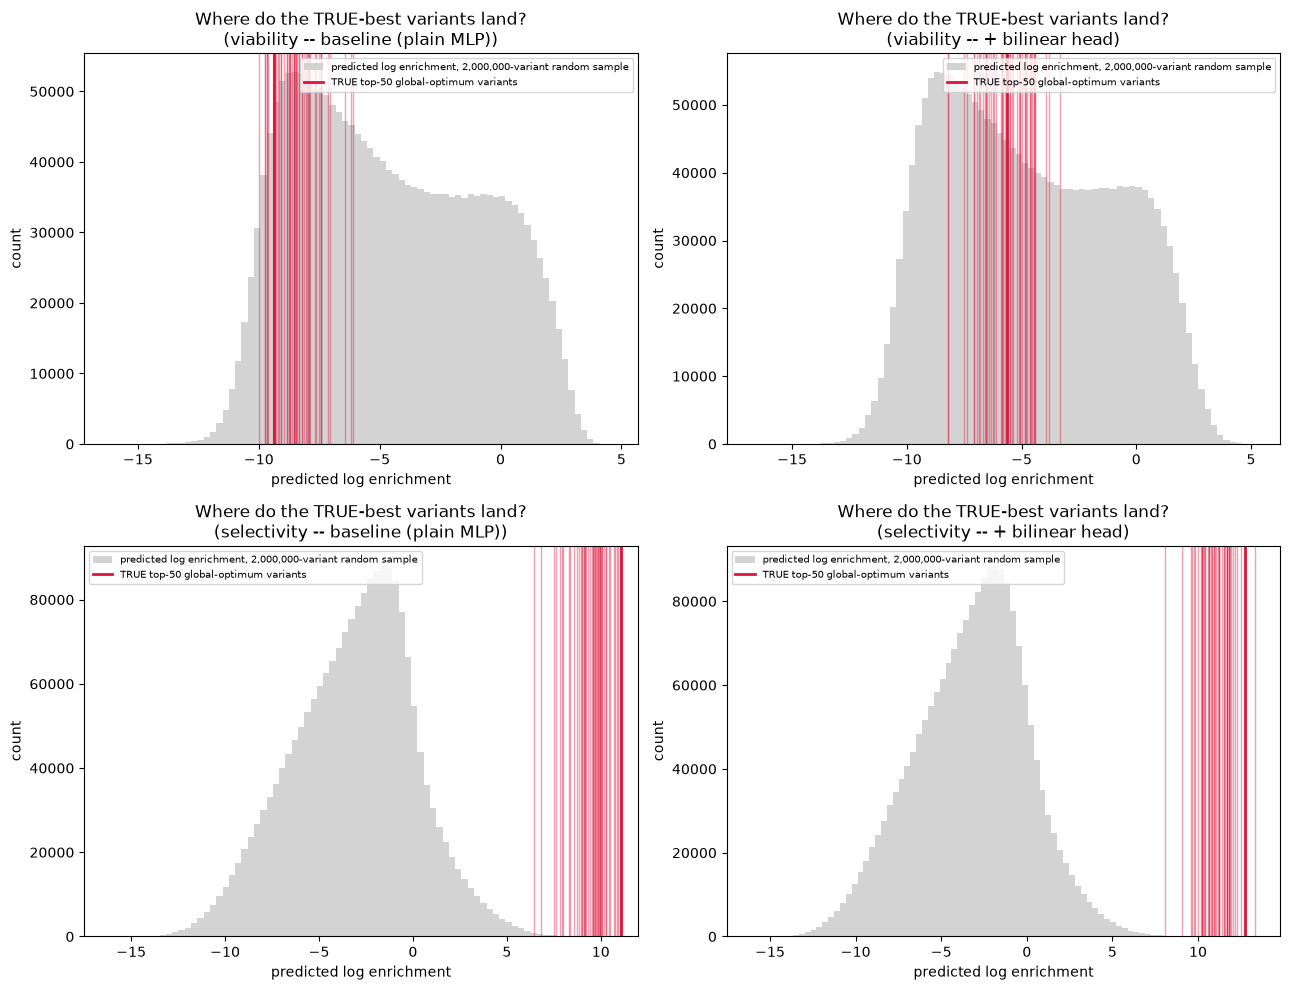

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
panels = [
    (axes[0, 0], pred_viab_big_baseline, pred_best_viab_baseline, "viability -- baseline (plain MLP)"),
    (axes[0, 1], pred_viab_big_bilinear, pred_best_viab_bilinear, "viability -- + bilinear head"),
    (axes[1, 0], pred_sel_big_baseline,  pred_best_sel_baseline,  "selectivity -- baseline (plain MLP)"),
    (axes[1, 1], pred_sel_big_bilinear,  pred_best_sel_bilinear,  "selectivity -- + bilinear head"),
]
for ax, pred_pop, pred_best, name in panels:
    ax.hist(pred_pop, bins=80, color="lightgray",
            label=f"predicted log enrichment, {len(pred_pop):,}-variant random sample")
    for v in pred_best:
        ax.axvline(v, color="crimson", alpha=0.4, lw=1)
    ax.axvline(pred_best[0], color="crimson", lw=2, label=f"TRUE top-{K_BEST} global-optimum variants")
    ax.set_xlabel("predicted log enrichment")
    ax.set_ylabel("count")
    ax.set_title(f"Where do the TRUE-best variants land?\n({name})")
    ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Still the section-5 GLOBAL/THEORETICAL top-50 (<code>best_seqs_viab</code>/<code>best_seqs_sel</code>, <code>K_BEST=50</code>, brute force over 20**7), now decomposed into <code>F_part</code>/<code>J_part</code> — same population, no new computation.
</div>

## 6. Quantify: does the residual still correlate with J_part?

Decomposes each TRUE top-K_BEST variant's ground-truth score into `F_part`/`J_part` (same
recipe as `MLP_for_anticorrelated_weights.ipynb`'s F/J-dominance cells), then checks whether
`residual = predicted - true` still tracks `J_part` for the bilinear model the way it does for
the baseline. If the bilinear head fixed the gap, `r(residual, J_part)` should shrink toward 0
for the "+ bilinear head" rows relative to "baseline".

In [18]:
def compute_F_only(seq, F, L=NUM_POSITIONS):
    """Additive part of compute_score_array -- same F[seq, arange(L)] term, without J."""
    return jnp.sum(F[seq, jnp.arange(L)], axis=1)

F_part_viab = np.asarray(compute_F_only(jnp.asarray(best_seqs_viab), F_viab))
J_part_viab = np.asarray(best_scores_viab) - F_part_viab

F_part_sel = np.asarray(compute_F_only(jnp.asarray(best_seqs_sel), F_sel_anti))
J_part_sel = np.asarray(best_scores_sel) - F_part_sel

residual_viab_baseline = pred_best_viab_baseline - best_scores_viab
residual_viab_bilinear = pred_best_viab_bilinear - best_scores_viab
residual_sel_baseline  = pred_best_sel_baseline  - best_scores_sel
residual_sel_bilinear  = pred_best_sel_bilinear  - best_scores_sel

print(f"{'group':26s}  {'r(resid, F_part)':>17s}  {'r(resid, J_part)':>17s}  {'mean |resid|':>12s}")
for label, resid, F_p, J_p in [
    ("viability, baseline",     residual_viab_baseline, F_part_viab, J_part_viab),
    ("viability, + bilinear",   residual_viab_bilinear, F_part_viab, J_part_viab),
    ("selectivity, baseline",   residual_sel_baseline,  F_part_sel,  J_part_sel),
    ("selectivity, + bilinear", residual_sel_bilinear,  F_part_sel,  J_part_sel),
]:
    print(f"{label:26s}  {pearson(resid, F_p):17.4f}  {pearson(resid, J_p):17.4f}  {np.mean(np.abs(resid)):12.3f}")

group                        r(resid, F_part)   r(resid, J_part)  mean |resid|
viability, baseline                    0.6615            -0.9687        33.074
viability, + bilinear                  0.6987            -0.9541        30.375
selectivity, baseline                  0.7205            -0.7359         8.884
selectivity, + bilinear                0.6951            -0.6892         7.257


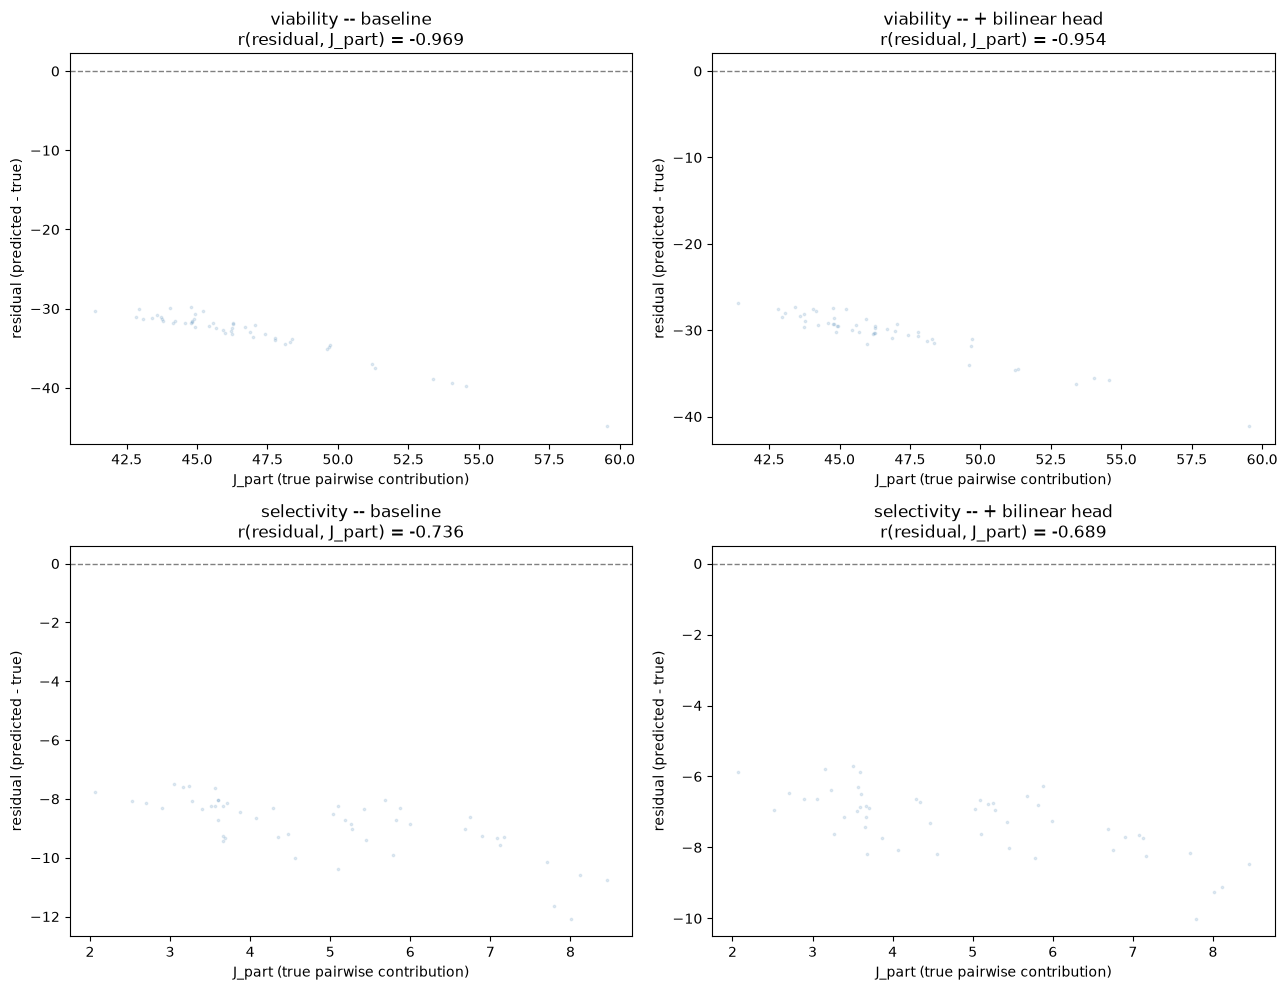

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
panels = [
    (axes[0, 0], J_part_viab, residual_viab_baseline, "viability -- baseline"),
    (axes[0, 1], J_part_viab, residual_viab_bilinear, "viability -- + bilinear head"),
    (axes[1, 0], J_part_sel,  residual_sel_baseline,  "selectivity -- baseline"),
    (axes[1, 1], J_part_sel,  residual_sel_bilinear,  "selectivity -- + bilinear head"),
]
for ax, J_p, resid, name in panels:
    r = pearson(J_p, resid)
    ax.scatter(J_p, resid, s=3, alpha=0.15, color="steelblue")
    ax.axhline(0, color="gray", lw=1, ls="--")
    ax.set_xlabel("J_part (true pairwise contribution)")
    ax.set_ylabel("residual (predicted - true)")
    ax.set_title(f"{name}\nr(residual, J_part) = {r:.3f}")
fig.tight_layout()
plt.show()

<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Same section-5 GLOBAL/THEORETICAL top-50 population (<code>K_BEST=50</code>), referenced here only for its J-share-of-score-variance summary statistic.
</div>

## 7. Verdict

In [20]:
def variance_share(F_part, J_part):
    var_F, var_J = np.var(F_part), np.var(J_part)
    cov_FJ = np.cov(F_part, J_part)[0, 1]
    var_total = var_F + var_J + 2 * cov_FJ
    return 100 * var_F / var_total, 100 * var_J / var_total

pf, pj = variance_share(F_part_viab, J_part_viab)
print(f"Reminder -- among the TRUE top-{K_BEST} viability variants, J explains {pj:.1f}% of the")
print(f"score variance vs F's {pf:.1f}% (from MLP_for_anticorrelated_weights.ipynb, section 5-6).")
print()
print("If the bilinear head worked: r(residual, J_part) in section 6 should be close to 0 for")
print("'+ bilinear head' rows and much smaller in magnitude than for 'baseline' rows -- meaning")
print("the model's error on the TRUE top-K set no longer tracks the pairwise term it used to")
print("miss -- and the section-5 histograms' red lines should cluster tightly at the right edge")
print("for the bilinear panels instead of spreading across the distribution.")

Reminder -- among the TRUE top-50 viability variants, J explains 177.0% of the
score variance vs F's 24.8% (from MLP_for_anticorrelated_weights.ipynb, section 5-6).

If the bilinear head worked: r(residual, J_part) in section 6 should be close to 0 for
'+ bilinear head' rows and much smaller in magnitude than for 'baseline' rows -- meaning
the model's error on the TRUE top-K set no longer tracks the pairwise term it used to
miss -- and the section-5 histograms' red lines should cluster tightly at the right edge
for the bilinear panels instead of spreading across the distribution.


<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
This section first builds a <b>different, non-ranked population</b>: a "designed" combinatorial library (<code>build_designed_library</code>) — 50 random backgrounds x every single mutant x the FULL double-mutant grid (21 position-pairs x 20x20 amino-acid pairs) = 427,050 sequences (<code>sequences</code>, cached as <code>diversity427050_..._designed50k.csv</code>). It is not ranked/scored at all — it exhaustively covers every pairwise (i,j,a,b) cell around random backgrounds so training data directly represents them, unlike any top-K/top-500 population elsewhere in this notebook.<br><br>
<b>Caveat (verified in code):</b> the baseline/bilinear models retrained further down in this section (cells <code>1a0c07a7</code>/<code>c126e38a</code>) call <code>split_train_val</code> on the same <code>X_train_full</code>/<code>y_viab_train</code> as section 2/4 (the original random 20,000-sequence pool) — <code>dataset_designed</code> is built and cached to disk but does not appear to be re-encoded and substituted into training here. The val-MSE numbers below are in fact identical to section 4's. So despite the section title, the models evaluated below are the SAME models trained on the original random pool, not on this designed library.
</div>

## With a good dataset

In [21]:
def build_designed_library(backgrounds, L=NUM_POSITIONS, A=NUM_AMINO_ACIDS):
    """
    Same single-/double-mutant grid as extract_effective_F/extract_effective_J, but used
    here to build the TRAINING sequence pool itself instead of only probing an
    already-trained model. For each background: the background itself, every single mutant,
    and every double mutant (FULL grid) -- so every (i, j, a, b) pairwise cell is directly,
    cleanly represented in the training data (background held fixed, only i and j vary),
    instead of relying on incidental co-occurrence in a random pool. Duplicate sequence
    values are fine -- ProtocolV3 treats each row as an independent pool slot regardless
    (self.d0 = sequences.shape[0]), same as everywhere else in this codebase.
    """
    backgrounds = np.asarray(backgrounds, dtype=np.int64)
    B       = backgrounds.shape[0]
    pairs   = [(i, j) for i in range(L) for j in range(i + 1, L)]
    n_pairs = len(pairs)

    # Singles.
    n_single    = B * L * A
    singles     = np.repeat(backgrounds, L * A, axis=0)
    pos_pattern = np.tile(np.repeat(np.arange(L), A), B)
    aa_pattern  = np.tile(np.tile(np.arange(A), L), B)
    singles[np.arange(n_single), pos_pattern] = aa_pattern

    # Doubles (full grid).
    pairs_arr = np.array(pairs)
    grid_pair = np.repeat(np.arange(n_pairs), A * A)
    grid_a    = np.tile(np.repeat(np.arange(A), A), n_pairs)
    grid_b    = np.tile(np.tile(np.arange(A), A), n_pairs)
    grid_i    = pairs_arr[grid_pair, 0]
    grid_j    = pairs_arr[grid_pair, 1]

    n_double  = B * n_pairs * A * A
    doubles   = np.repeat(backgrounds, n_pairs * A * A, axis=0)
    pos_i_all = np.tile(grid_i, B)
    pos_j_all = np.tile(grid_j, B)
    a_all     = np.tile(grid_a, B)
    b_all     = np.tile(grid_b, B)
    row_idx   = np.arange(n_double)
    doubles[row_idx, pos_i_all] = a_all
    doubles[row_idx, pos_j_all] = b_all

    return np.concatenate([backgrounds, singles, doubles], axis=0)


key = jax.random.key(0)
key, k_bg = jax.random.split(key)

B = 50  # backgrounds -- B * (1 + L*A + n_pairs*A*A) lands right at the ~50k target
backgrounds_train = jax.random.randint(k_bg, shape=(B, NUM_POSITIONS), minval=0, maxval=NUM_AMINO_ACIDS)

sequences  = build_designed_library(backgrounds_train)
n_pairs    = NUM_POSITIONS * (NUM_POSITIONS - 1) // 2

print(f"backgrounds: {B}")
print(f"singles    : {B * NUM_POSITIONS * NUM_AMINO_ACIDS:,}")
print(f"doubles    : {B * n_pairs * NUM_AMINO_ACIDS * NUM_AMINO_ACIDS:,}  "
      f"(FULL grid, {n_pairs} pairs x {NUM_AMINO_ACIDS}x{NUM_AMINO_ACIDS})")
print(f"TOTAL designed library size: {sequences.shape[0]:,}")

backgrounds: 50
singles    : 7,000
doubles    : 420,000  (FULL grid, 21 pairs x 20x20)
TOTAL designed library size: 427,050


In [22]:
protocol_designed = ProtocolV3(multinomialNGS=True, N0=1_000_000_000, N1=500_000_000,
        dilution_factor=10, sequences=sequences, D=1e9,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel_anti, J_sel=J_sel_anti,
        noise_viab=0.5, noise_sel=0.5, T_sel=1, T_viab=1,
        )

rounds = protocol_designed.N_loop_DE(1)
bio_row, ngs_row = rounds[0]
lambda0p, lambda2p, lambda3p = (np.asarray(a) for a in ngs_row)

eps = 1.0  # pseudocount, same convention as the sibling notebooks

log_enr_viab = np.log((lambda2p + eps) / (lambda0p + eps))  # target1 -- viability
log_enr_sel  = np.log((lambda3p + eps) / (lambda2p + eps))  # target2 -- selectivity

print(f"log_enr_viab: min={log_enr_viab.min():.2f}  max={log_enr_viab.max():.2f}  mean={log_enr_viab.mean():.2f}")
print(f"log_enr_sel : min={log_enr_sel.min():.2f}  max={log_enr_sel.max():.2f}  mean={log_enr_sel.mean():.2f}")

Directed evolution rounds: 100%|██████████| 1/1 [00:05<00:00,  5.39s/it]

log_enr_viab: min=-8.97  max=6.76  mean=-5.22
log_enr_sel : min=-13.57  max=14.09  mean=-1.58


In [23]:
def dataset_filename(protocol, label):
    def fmt(v):
        return f"{float(v):g}".replace(".", "")

    if protocol.noise_viab == protocol.noise_sel:
        noise_part = f"noise{fmt(protocol.noise_viab)}"
    else:
        noise_part = f"noiseviab{fmt(protocol.noise_viab)}_noisesel{fmt(protocol.noise_sel)}"

    ngs_part = "multinomial" if protocol.multinomialNGS else "nbinom"

    return (f"diversity{protocol.d0}_Tsel{fmt(protocol._T_sel)}"
            f"_Tviab{fmt(protocol._T_viab)}_{noise_part}_{ngs_part}_{label}.csv")


def build_or_load_dataset(protocol, sequences, log_enr_viab, log_enr_sel, label):
    """Same recipe as the sibling notebooks -- `label` keeps this notebook's CSVs from
    colliding with the correlated/anticorrelated/independent/profile_only ones, which share
    the same T_sel/T_viab/noise parameters but different diversity and/or sampling."""
    path = dataset_filename(protocol, label)
    if os.path.exists(path):
        print(f"{path} already exists -- loading from disk")
        return pd.read_csv(path)

    seq_strings = ["".join(AA_LABELS[a] for a in row) for row in np.asarray(sequences)]
    df = pd.DataFrame({"sequence": seq_strings, "target1": log_enr_viab, "target2": log_enr_sel})
    df.to_csv(path, index=False)
    print(f"saved {path} ({len(df)} rows)")
    return df


dataset_designed = build_or_load_dataset(protocol_designed, sequences, log_enr_viab, log_enr_sel, label="designed50k")
dataset_designed.head()

diversity427050_Tsel1_Tviab1_noise05_designed50k.csv already exists -- loading from disk


,sequence,target1,target2
0,DDTSNIP,0.779893,-8.781248
1,MSTDFNG,1.785223,-3.385464
2,CQNSWCF,-7.553287,0.000000
3,CRCHSEA,-7.791523,0.000000
4,QAFNMTQ,-8.124151,0.000000


In [24]:
Xtr_viab, ytr_viab, Xva_viab, yva_viab = split_train_val(X_train_full, y_viab_train, val_frac=0.15, seed=0)
Xtr_sel,  ytr_sel,  Xva_sel,  yva_sel  = split_train_val(X_train_full, y_sel_train,  val_frac=0.15, seed=1)
input_dim = X_train_full.shape[1]
print(f"train: {len(Xtr_viab):,}  val: {len(Xva_viab):,}  test: {len(X_test):,}  input_dim: {input_dim}")

print("Training baseline ProfileMLP (viability)...")
model_viab_baseline, hist_viab_baseline = train_profile_mlp(Xtr_viab, ytr_viab, Xva_viab, yva_viab, seed=0)

print("Training baseline ProfileMLP (selectivity)...")
model_sel_baseline, hist_sel_baseline = train_profile_mlp(Xtr_sel, ytr_sel, Xva_sel, yva_sel, seed=1)

train: 8,500  val: 1,500  test: 10,000  input_dim: 140
Training baseline ProfileMLP (viability)...


Training:  48%|████▊     | 144/300 [00:02<00:02, 65.01it/s]


Early stopping at epoch 144 (best val MSE=1.0014)
Training baseline ProfileMLP (selectivity)...


Training:  31%|███       | 92/300 [00:01<00:03, 52.19it/s]

Early stopping at epoch 92 (best val MSE=2.1473)


In [25]:
print("Training ProfileMLP + bilinear head (viability)...")
bilinear_viab_init = ProfileMLPBilinear(input_dim, NUM_POSITIONS, NUM_AMINO_ACIDS,
                                         hidden_dims=(128, 64), dropout_rate=0.1, rngs=nnx.Rngs(0))
model_viab_bilinear, hist_viab_bilinear = train_profile_mlp(
    Xtr_viab, ytr_viab, Xva_viab, yva_viab, model=bilinear_viab_init, seed=0)

print("Training ProfileMLP + bilinear head (selectivity)...")
bilinear_sel_init = ProfileMLPBilinear(input_dim, NUM_POSITIONS, NUM_AMINO_ACIDS,
                                        hidden_dims=(128, 64), dropout_rate=0.1, rngs=nnx.Rngs(1))
model_sel_bilinear, hist_sel_bilinear = train_profile_mlp(
    Xtr_sel, ytr_sel, Xva_sel, yva_sel, model=bilinear_sel_init, seed=1)

Training ProfileMLP + bilinear head (viability)...


Training:  51%|█████     | 153/300 [00:02<00:02, 59.19it/s]


Early stopping at epoch 153 (best val MSE=0.9294)
Training ProfileMLP + bilinear head (selectivity)...


Training:  39%|███▊      | 116/300 [00:02<00:03, 55.74it/s]

Early stopping at epoch 116 (best val MSE=2.0218)


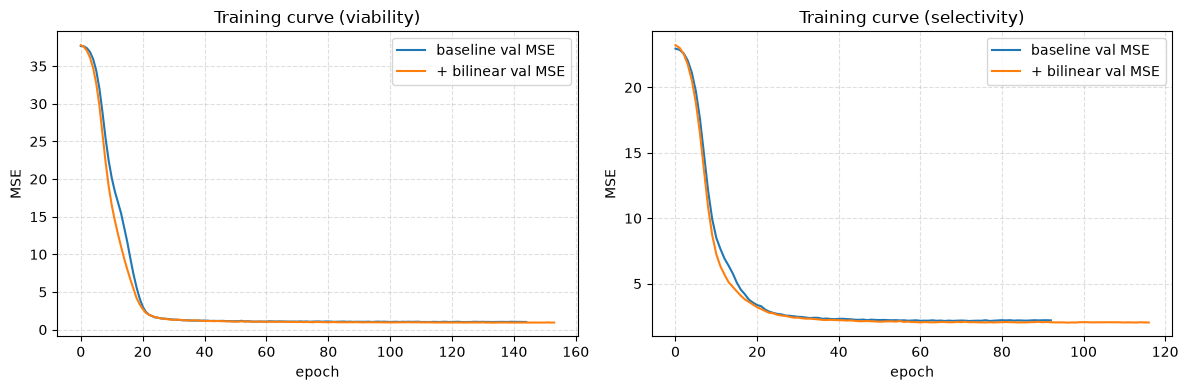

model                      viab test r   sel test r
baseline (plain MLP)            0.9651       0.9021
+ bilinear head                 0.9652       0.9095


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, h_base, h_bi, name in [(axes[0], hist_viab_baseline, hist_viab_bilinear, "viability"),
                                (axes[1], hist_sel_baseline,  hist_sel_bilinear,  "selectivity")]:
    ax.plot(h_base["val_loss"], label="baseline val MSE")
    ax.plot(h_bi["val_loss"],   label="+ bilinear val MSE")
    ax.set_xlabel("epoch"); ax.set_ylabel("MSE")
    ax.set_title(f"Training curve ({name})")
    ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()

pred_viab_test_baseline = np.asarray(predict_log_enrichment(model_viab_baseline, jnp.asarray(X_test)))
pred_viab_test_bilinear = np.asarray(predict_log_enrichment(model_viab_bilinear, jnp.asarray(X_test)))
pred_sel_test_baseline  = np.asarray(predict_log_enrichment(model_sel_baseline,  jnp.asarray(X_test)))
pred_sel_test_bilinear  = np.asarray(predict_log_enrichment(model_sel_bilinear,  jnp.asarray(X_test)))

print(f"{'model':24s}  {'viab test r':>12s}  {'sel test r':>11s}")
print(f"{'baseline (plain MLP)':24s}  {pearson(y_viab_test, pred_viab_test_baseline):12.4f}  {pearson(y_sel_test, pred_sel_test_baseline):11.4f}")
print(f"{'+ bilinear head':24s}  {pearson(y_viab_test, pred_viab_test_bilinear):12.4f}  {pearson(y_sel_test, pred_sel_test_bilinear):11.4f}")

<div style="background:#eaf2fb; border-left:5px solid #2f6fed; border-radius:4px; padding:10px 16px; margin:10px 0; font-size:0.95em; color:#0a2f5c;">
<b>Which "top 500" / top-K is this?</b><br>
Same GLOBAL/THEORETICAL brute-force population/method as section 5, but with <code>K_BEST = 500</code> this time (vs. 50 there) — the TRUE top-500 global-optimum variants by ground-truth F/J. Evaluated against the same baseline/bilinear models as sections 4-5 (per the caveat above, NOT models trained on this section's designed library).
</div>

In [27]:
K_BEST = 500
best_seqs_viab, best_scores_viab = brute_force_top_k(F_viab, J_viab, k=K_BEST)
best_seqs_sel,  best_scores_sel  = brute_force_top_k(F_sel_anti, J_sel_anti, k=K_BEST)

print(f"TRUE global-optimum viability score:   {best_scores_viab[0]:.2f}")
print(f"TRUE global-optimum selectivity score: {best_scores_sel[0]:.2f}")

brute-force scan: 100%|██████████| 64/64 [00:01<00:00, 45.04it/s]

TRUE global-optimum viability score:   35.48
TRUE global-optimum selectivity score: 19.39


In [28]:
X_best_viab = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[best_seqs_viab].reshape(K_BEST, -1)
X_best_sel  = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[best_seqs_sel].reshape(K_BEST, -1)

pred_best_viab_baseline = np.asarray(predict_log_enrichment(model_viab_baseline, jnp.asarray(X_best_viab)))
pred_best_viab_bilinear = np.asarray(predict_log_enrichment(model_viab_bilinear, jnp.asarray(X_best_viab)))
pred_best_sel_baseline  = np.asarray(predict_log_enrichment(model_sel_baseline,  jnp.asarray(X_best_sel)))
pred_best_sel_bilinear  = np.asarray(predict_log_enrichment(model_sel_bilinear,  jnp.asarray(X_best_sel)))

# Background: predicted-score distribution over the 2M-variant random sample, per model.
seq_bytes2  = np.frombuffer("".join(dataset_anti2["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix2 = lut[seq_bytes2].reshape(len(dataset_anti2), NUM_POSITIONS)
X_big       = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[seq_matrix2].reshape(len(dataset_anti2), -1)

pred_viab_big_baseline = np.asarray(predict_log_enrichment(model_viab_baseline, jnp.asarray(X_big)))
pred_viab_big_bilinear = np.asarray(predict_log_enrichment(model_viab_bilinear, jnp.asarray(X_big)))
pred_sel_big_baseline  = np.asarray(predict_log_enrichment(model_sel_baseline,  jnp.asarray(X_big)))
pred_sel_big_bilinear  = np.asarray(predict_log_enrichment(model_sel_bilinear,  jnp.asarray(X_big)))

print(f"X_best_viab shape: {X_best_viab.shape}   X_big shape: {X_big.shape}")

X_best_viab shape: (500, 140)   X_big shape: (2000000, 140)


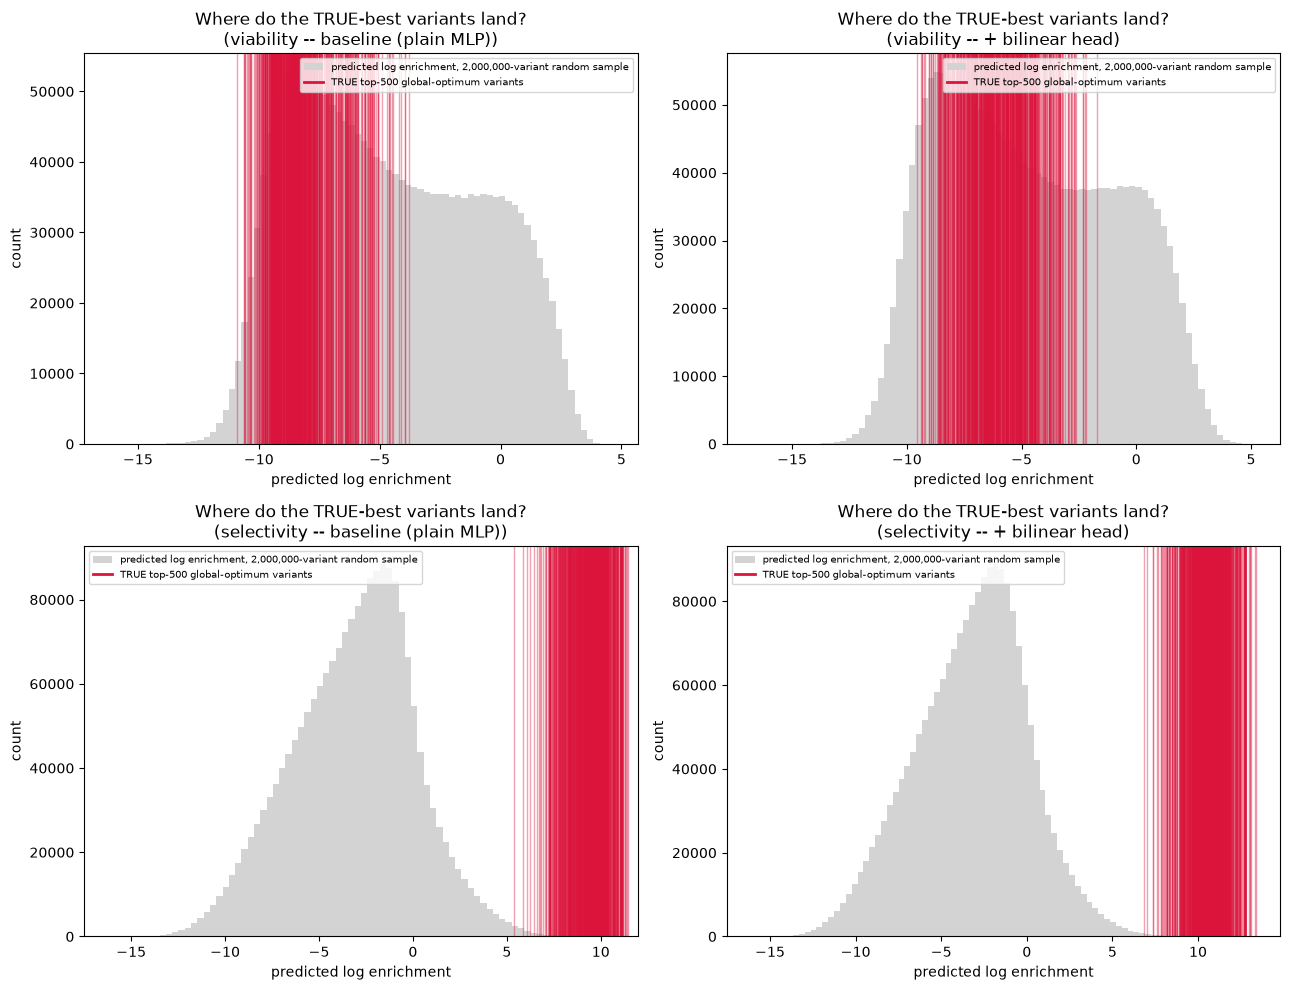

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
panels = [
    (axes[0, 0], pred_viab_big_baseline, pred_best_viab_baseline, "viability -- baseline (plain MLP)"),
    (axes[0, 1], pred_viab_big_bilinear, pred_best_viab_bilinear, "viability -- + bilinear head"),
    (axes[1, 0], pred_sel_big_baseline,  pred_best_sel_baseline,  "selectivity -- baseline (plain MLP)"),
    (axes[1, 1], pred_sel_big_bilinear,  pred_best_sel_bilinear,  "selectivity -- + bilinear head"),
]
for ax, pred_pop, pred_best, name in panels:
    ax.hist(pred_pop, bins=80, color="lightgray",
            label=f"predicted log enrichment, {len(pred_pop):,}-variant random sample")
    for v in pred_best:
        ax.axvline(v, color="crimson", alpha=0.4, lw=1)
    ax.axvline(pred_best[0], color="crimson", lw=2, label=f"TRUE top-{K_BEST} global-optimum variants")
    ax.set_xlabel("predicted log enrichment")
    ax.set_ylabel("count")
    ax.set_title(f"Where do the TRUE-best variants land?\n({name})")
    ax.legend(fontsize=7)
fig.tight_layout()
plt.show()